## Process output of simulations

1. Create mean gdfs from simulation runs
2. Create difference gdfs between basecase and policy implementation
3. Create average mode stats
4. Investigate stochasticity of results

In [1]:
import os
import glob
import gzip
import math
import random
import pickle

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.colors import LogNorm
import shapely.wkt as wkt
from shapely.geometry import Point, LineString, box
from shapely.ops import nearest_points
import lxml.etree as ET
import tqdm
import matplotlib.pyplot as plt
import processing_io as pio
import re 

districts = gpd.read_file("../../../../data/visualisation/districts_paris.geojson")

# Parameters to adapt
districts_of_policy_implementation = [5, 6, 7]
is_for_1pm = False
plot_in_percentage = True

string_is_for_1pm = "pop_1pm" if is_for_1pm else "pop_1pct"
string_district_of_interest = "_".join([str(d) for d in districts_of_policy_implementation])

path = "../../../../data/" +  string_is_for_1pm + "_simulations/"
basecase_subdir = pio.get_subdirs(path + string_is_for_1pm + "_basecase/")
comparison_subdir = pio.get_subdirs(path + string_is_for_1pm + "_policy_in_zone_2")

result_path_basecase_mean = "results/" + string_is_for_1pm + "_basecase_average_output_links.geojson"
result_path_comparison_mean = "results/gdf_" + string_is_for_1pm + "_policy_in_" + string_district_of_interest + ".geojson"
result_path_difference = "results/gdf_" + string_is_for_1pm + "_difference.geojson"

compute_comparison_with_basecase = False

In [2]:
random_seed_2_df_basecase_output_links = pio.create_dic_seed_2_output_links(subdir=basecase_subdir)
random_seed_2_df_basecase_trips = pio.create_dic_seed_2_eqasim_trips_given_output_trips(subdir=basecase_subdir)
basecase_output_links_gdfs = list(random_seed_2_df_basecase_output_links.values())
gdf_basecase_mean = pio.compute_average_or_median_geodataframe(geodataframes=basecase_output_links_gdfs, column_name="vol_car", is_mean=True)
gdf_basecase_mean = gdf_basecase_mean.rename(columns={"osm:way:highway": "highway"})
gdf_basecase_mean.to_file(result_path_basecase_mean, driver='GeoJSON')

In [3]:
random_seed_2_df_basecase_trips['{1}']

,person,trip_number,trip_id,dep_time,trav_time,wait_time,traveled_distance,euclidean_distance,main_mode,longest_distance_mode,...,start_facility_id,start_link,start_x,start_y,end_facility_id,end_link,end_x,end_y,first_pt_boarding_stop,last_pt_egress_stop
0,1,1,1_1,09:41:29,00:12:46,00:00:00,920,707,walk,walk,...,home_1,262151,649869.120000,6.860582e+06,sec_409991,515043,649443.100000,6.860017e+06,NaN,NaN
1,1,2,1_2,11:11:29,00:14:24,00:00:00,1370,1038,pt,walk,...,sec_409991,515043,649443.100000,6.860017e+06,sec_229585,537320,649222.230000,6.861031e+06,NaN,NaN
2,10,1,10_1,10:26:16,00:08:21,00:00:00,602,463,walk,walk,...,home_7,43330,656662.136372,6.860692e+06,outside_1,482724,657116.961349,6.860780e+06,NaN,NaN
3,10,2,10_2,15:56:16,00:00:01,00:00:00,1802,1801,outside,outside,...,outside_1,482724,657116.961349,6.860780e+06,outside_2,112845,658918.022379,6.860728e+06,NaN,NaN
4,10,3,10_3,16:01:41,00:02:01,00:00:00,146,111,walk,walk,...,outside_2,112845,658918.022379,6.860728e+06,outside_3,118289,658968.557163,6.860628e+06,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142753,9997623,2,9997623_2,11:20:19,00:05:11,00:00:00,2147,1518,car,car,...,work_2343689,561817,652993.810000,6.859080e+06,outside_26,108473,653508.573590,6.857651e+06,NaN,NaN
142754,9998180,1,9998180_1,07:13:33,00:07:09,00:00:00,3794,2547,car_passenger,car_passenger,...,outside_116,108472,653521.987413,6.857658e+06,edu_11045,581070,651724.100000,6.859464e+06,NaN,NaN
142755,9998180,2,9998180_2,16:45:23,00:28:42,00:00:00,3540,2630,pt,pt,...,edu_11045,581070,651724.100000,6.859464e+06,outside_57,339663,654302.838874,6.858944e+06,NaN,NaN
142756,9998181,1,9998181_1,10:50:30,00:29:14,00:00:00,6152,5457,pt,pt,...,outside_57,339663,654302.838874,6.858944e+06,work_2351574,260151,650788.900000,6.863119e+06,NaN,NaN


In [4]:
# Helper function to convert time strings to total seconds
def convert_time_to_seconds(df, column_name):
    df[column_name] = pd.to_timedelta(df[column_name]).dt.total_seconds()
    return df

# Calculate average travel time, routed distance, and trip count per mode across all seeds
def calculate_avg_mode_stats(single_mode_stats_list: list):
    mode_stats_list = []

    for df in single_mode_stats_list:
        # Convert 'trav_time' to total seconds for aggregation
        df = convert_time_to_seconds(df, 'trav_time')

        # Aggregate travel time, traveled distance, and trip count by main mode
        mode_stats = df.groupby('main_mode').agg({
            'trav_time': 'sum',
            'traveled_distance': 'sum',
            'trip_id': 'count'  # Count trips by counting unique trip_ids
        }).reset_index()
        mode_stats_list.append(mode_stats)

    # Concatenate all mode_stats dataframes
    all_mode_stats = pd.concat(mode_stats_list, ignore_index=True)

    # Calculate the average across all seeds
    average_mode_stats = all_mode_stats.groupby('main_mode').agg({
        'trav_time': 'mean',
        'traveled_distance': 'mean',
        'trip_id': 'mean'  # Calculate average trip count
    }).reset_index()

    # Rename columns for clarity
    average_mode_stats.columns = ['main_mode', 'avg_trav_time_seconds', 'avg_traveled_distance', 'average_trip_count']
    
    return average_mode_stats

df_average_mode_stats = calculate_avg_mode_stats(random_seed_2_df_basecase_trips.values())
df_average_mode_stats.to_csv("results/pop_1pct_basecase_average_mode_stats.csv", index=False)

In [5]:
if compute_comparison_with_basecase:
    random_seed_2_df_comparison = pio.create_dic_seed_2_output_links(subdir = comparison_subdir)
    geodataframes_comparison = list(random_seed_2_df_comparison.values())
    gdf_comparison_mean = pio.compute_average_or_median_geodataframe(geodataframes=geodataframes_comparison, column_name="vol_car", is_mean=True)
    gdf_comparison_mean_extended = pio.extend_geodataframe(gdf_base = gdf_basecase_mean, gdf_to_extend=gdf_comparison_mean, column_to_extend='highway', new_column_name='highway')
    gdf_basecase_without_unnecessary_columns = pio.remove_columns(gdf_with_correct_columns=gdf_comparison_mean_extended, gdf_to_be_adapted=gdf_basecase_mean)
    gdf_basecase_difference = pio.compute_difference_geodataframe(gdf_to_substract_from=gdf_comparison_mean_extended, gdf_to_substract=gdf_basecase_without_unnecessary_columns, column_name= 'vol_car')
    gdf_comparison_mean_extended.to_file(result_path_comparison_mean, driver='GeoJSON')
    gdf_basecase_difference.to_file(result_path_difference, driver='GeoJSON')

In [6]:
def calculate_edge_metrics(simulation_gdfs, mean_gdf):
    edge_volumes = {}
    # Collect volumes for each edge across all simulations
    for df in simulation_gdfs:
        for idx, row in df.iterrows():
            link = row['link']
            volume = row['vol_car']
            if link not in edge_volumes:
                edge_volumes[link] = []
            edge_volumes[link].append(volume)
            
    variances = {link: np.var(np.array(volumes)) for link, volumes in edge_volumes.items()}
    cvs = {link: (np.std(np.array(volumes)) / np.mean(np.array(volumes)) * 100) if np.mean(np.array(volumes)) != 0 else 0 for link, volumes in edge_volumes.items()}
    std_devs = {link: np.std(np.array(volumes)) for link, volumes in edge_volumes.items()}
    
    # Add metrics to the mean_gdf
    mean_gdf['variance'] = mean_gdf['link'].map(variances)
    mean_gdf['cv_percent'] = mean_gdf['link'].map(cvs)  # Coefficient of Variation as percentage
    mean_gdf['std_dev'] = mean_gdf['link'].map(std_devs)
    return mean_gdf

# Apply the function to add variance metrics
gdf_basecase_mean = calculate_edge_metrics(basecase_output_links_gdfs, gdf_basecase_mean)

In [7]:
def print_edge_metrics(mean_gdf):
    # Compute and print the mean car volume over all edges
    mean_car_volume = mean_gdf['vol_car'].mean()
    print(f"Mean Car Volume over all edges: {mean_car_volume:.2f}")
    
    num_observations = len(mean_gdf)
    print(f"Number of observations (links): {num_observations}")
    
    # Compute and print the mean variance over all edges
    mean_variance = mean_gdf['variance'].mean()
    print(f"Mean Variance over all edges: {mean_variance:.2f}")

    # Compute and print the mean Coefficient of Variation (CV) over all edges
    mean_cv_percent = mean_gdf['cv_percent'].mean()
    print(f"Mean Coefficient of Variation (CV) over all edges: {mean_cv_percent:.2f}%")
    
    # Compute and print the mean of the standard deviations over all edges
    mean_std_dev = mean_gdf['std_dev'].mean()
    print(f"Mean Standard Deviation over all edges: {mean_std_dev:.2f}")
    
    print("\nMetrics by highway type:")
    # Compute and print metrics by highway type
    highway_types = ['trunk', 'primary', 'secondary', 'tertiary', 'residential', 'living_street']
    for highway in highway_types:
        highway_gdf = mean_gdf[mean_gdf['highway'] == highway]
        
        highway_mean_car_volume = highway_gdf['vol_car'].mean()
        print(f"\nMean Car Volume for {highway} roads: {highway_mean_car_volume:.2f}")
        
        num_highway_observations = len(highway_gdf)
        print(f"Number of observations for {highway} roads: {num_highway_observations}")
        
        highway_mean_variance = highway_gdf['variance'].mean()
        print(f"Mean Variance for {highway} roads: {highway_mean_variance:.2f}")
        
        highway_mean_cv = highway_gdf['cv_percent'].mean()
        print(f"Mean Coefficient of Variation (CV) for {highway} roads: {highway_mean_cv:.2f}%")
        
        highway_mean_std_dev = highway_gdf['std_dev'].mean()
        print(f"Mean Standard Deviation for {highway} roads: {highway_mean_std_dev:.2f}")

# Apply the function to print variance metrics
print_edge_metrics(gdf_basecase_mean)

Mean Car Volume over all edges: 50.91
Number of observations (links): 31635
Mean Variance over all edges: 8.57
Mean Coefficient of Variation (CV) over all edges: 19.47%
Mean Standard Deviation over all edges: 2.10

Metrics by highway type:

Mean Car Volume for trunk roads: 1061.25
Number of observations for trunk roads: 358
Mean Variance for trunk roads: 32.26
Mean Coefficient of Variation (CV) for trunk roads: 0.55%
Mean Standard Deviation for trunk roads: 5.52

Mean Car Volume for primary roads: 117.59
Number of observations for primary roads: 5067
Mean Variance for primary roads: 19.68
Mean Coefficient of Variation (CV) for primary roads: 9.97%
Mean Standard Deviation for primary roads: 3.71

Mean Car Volume for secondary roads: 51.43
Number of observations for secondary roads: 4260
Mean Variance for secondary roads: 12.84
Mean Coefficient of Variation (CV) for secondary roads: 15.08%
Mean Standard Deviation for secondary roads: 2.98

Mean Car Volume for tertiary roads: 35.33
Number

In [8]:
len(basecase_output_links_gdfs)

98

# Get upper bounds for each metric

We find that the variance bounds the MSE, and the standard deviation bounds the RMSE from below.

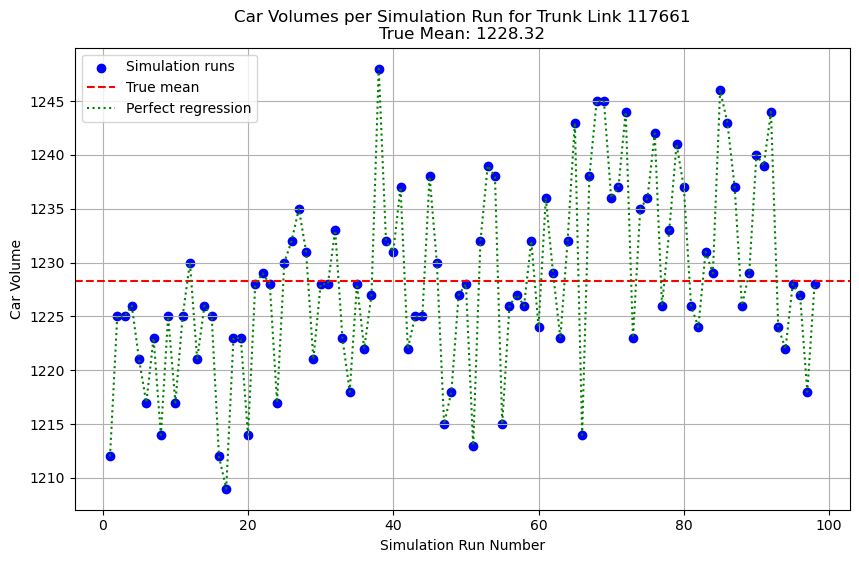

True mean: 1228.32
Number of simulation runs: 98
Standard deviation: 8.65


In [9]:
# Get one trunk link
trunk_link = gdf_basecase_mean[gdf_basecase_mean['highway'] == 'trunk']['link'].iloc[0]

# Get the true mean volume from gdf_basecase_mean
true_mean = gdf_basecase_mean[gdf_basecase_mean['link'] == trunk_link]['vol_car'].iloc[0]

# Get all simulated volumes for this link from different runs
simulated_volumes = []
for df in basecase_output_links_gdfs:
    if trunk_link in df['link'].values:
        volume = df[df['link'] == trunk_link]['vol_car'].iloc[0]
        simulated_volumes.append(volume)

# Create x-axis (simulation run numbers)
run_numbers = range(1, len(simulated_volumes) + 1)

# Create plot
plt.figure(figsize=(10, 6))

# Plot simulated volumes
plt.scatter(run_numbers, simulated_volumes, color='blue', label='Simulation runs')

# Plot mean line
plt.axhline(y=true_mean, color='r', linestyle='--', label='True mean')

# Plot "perfect" regression line (y=x scaled to our data range)
# This would represent perfect correlation between runs
plt.plot(run_numbers, simulated_volumes, color='green', linestyle=':', label='Perfect regression')

plt.xlabel('Simulation Run Number')
plt.ylabel('Car Volume')
plt.title(f'Car Volumes per Simulation Run for Trunk Link {trunk_link}\nTrue Mean: {true_mean:.2f}')
plt.legend()
plt.grid(True)
plt.show()

# Print some statistics
print(f"True mean: {true_mean:.2f}")
print(f"Number of simulation runs: {len(simulated_volumes)}")
print(f"Standard deviation: {np.std(simulated_volumes):.2f}")

/Users/elenanatterer/anaconda3/envs/Paris_Analysis/lib/python3.10/site-packages/scipy/stats/_distn_infrastructure.py:2351: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
/Users/elenanatterer/anaconda3/envs/Paris_Analysis/lib/python3.10/site-packages/scipy/stats/_distn_infrastructure.py:2352: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


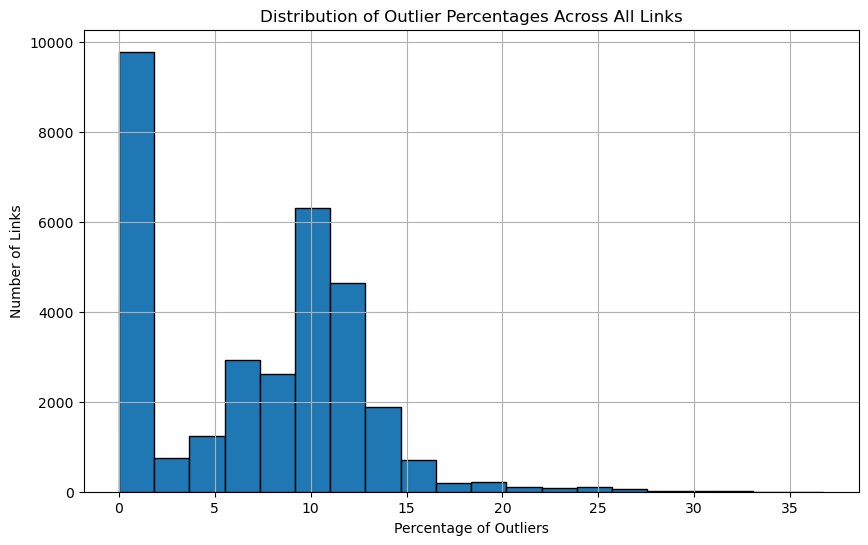


Outlier Analysis by Highway Type:

Highway type: residential
Mean percentage of outliers: 7.45%
Number of links: 11796
Mean car volume: 13.26

Highway type: tertiary
Mean percentage of outliers: 8.39%
Number of links: 3751
Mean car volume: 35.33

Highway type: living_street
Mean percentage of outliers: 6.96%
Number of links: 732
Mean car volume: 4.79

Highway type: secondary
Mean percentage of outliers: 8.19%
Number of links: 4260
Mean car volume: 51.43

Highway type: primary
Mean percentage of outliers: 8.29%
Number of links: 5067
Mean car volume: 117.59

Highway type: trunk_link
Mean percentage of outliers: 8.96%
Number of links: 407
Mean car volume: 142.41

Highway type: primary_link
Mean percentage of outliers: 7.28%
Number of links: 228
Mean car volume: 55.50

Highway type: motorway
Mean percentage of outliers: 0.44%
Number of links: 285
Mean car volume: 70.72

Highway type: nan
Mean percentage of outliers: nan%
Number of links: 0
Mean car volume: nan

Highway type: service
Mean 

In [11]:
def calculate_outliers_percentage(simulation_gdfs, mean_gdf):
    """
    Calculate what percentage of simulation outcomes fall outside the 90% confidence interval for each link.
    
    Parameters:
    -----------
    simulation_gdfs : list
        List of GeoDataFrames containing simulation results
    mean_gdf : GeoDataFrame
        GeoDataFrame containing mean values for each link
        
    Returns:
    --------
    GeoDataFrame
        Updated mean_gdf with additional columns for outlier analysis:
        - outlier_percentage: Percentage of runs that are outliers
        - ci_lower: Lower bound of 90% confidence interval
        - ci_upper: Upper bound of 90% confidence interval
        - num_outliers: Number of runs that are outliers
        - total_runs: Total number of runs for this link
    """
    # Input validation
    if not isinstance(simulation_gdfs, list) or len(simulation_gdfs) == 0:
        raise ValueError("simulation_gdfs must be a non-empty list")
    if not isinstance(mean_gdf, gpd.GeoDataFrame) or mean_gdf.empty:
        raise ValueError("mean_gdf must be a non-empty GeoDataFrame")
    
    edge_volumes = {}
    # Collect volumes for each edge across all simulations
    for df in simulation_gdfs:
        if not isinstance(df, gpd.GeoDataFrame):
            raise ValueError("Each item in simulation_gdfs must be a GeoDataFrame")
        if 'link' not in df.columns or 'vol_car' not in df.columns:
            raise ValueError("Each GeoDataFrame must contain 'link' and 'vol_car' columns")
        for idx, row in df.iterrows():
            link = row['link']
            volume = row['vol_car']
            if link not in edge_volumes:
                edge_volumes[link] = []
            edge_volumes[link].append(volume)
    
    # Calculate statistics for each link
    outlier_stats = {}
    for link, volumes in edge_volumes.items():
        if len(volumes) < 2:
            print(f"Warning: Link {link} has less than 2 data points, skipping")
            continue
            
        volumes_array = np.array(volumes)
        mean = np.mean(volumes_array)
        std = np.std(volumes_array)
        
        # Calculate 90% confidence interval
        ci_lower, ci_upper = stats.norm.interval(0.90, loc=mean, scale=std)
        
        # Count values outside the interval
        outliers = np.sum((volumes_array < ci_lower) | (volumes_array > ci_upper))
        outlier_percentage = (outliers / len(volumes_array)) * 100
        
        outlier_stats[link] = {
            'outlier_percentage': outlier_percentage,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper,
            'num_outliers': outliers,
            'total_runs': len(volumes_array)
        }
    
    # Add statistics to the mean_gdf
    mean_gdf['outlier_percentage'] = mean_gdf['link'].map(lambda x: outlier_stats.get(x, {}).get('outlier_percentage', np.nan))
    mean_gdf['ci_lower'] = mean_gdf['link'].map(lambda x: outlier_stats.get(x, {}).get('ci_lower', np.nan))
    mean_gdf['ci_upper'] = mean_gdf['link'].map(lambda x: outlier_stats.get(x, {}).get('ci_upper', np.nan))
    mean_gdf['num_outliers'] = mean_gdf['link'].map(lambda x: outlier_stats.get(x, {}).get('num_outliers', np.nan))
    mean_gdf['total_runs'] = mean_gdf['link'].map(lambda x: outlier_stats.get(x, {}).get('total_runs', np.nan))
    
    return mean_gdf

# Run the outlier analysis
gdf_basecase_mean = calculate_outliers_percentage(basecase_output_links_gdfs, gdf_basecase_mean)

# Plot histogram of outlier percentages
plt.figure(figsize=(10, 6))
plt.hist(gdf_basecase_mean['outlier_percentage'].dropna(), bins=20, edgecolor='black')
plt.xlabel('Percentage of Outliers')
plt.ylabel('Number of Links')
plt.title('Distribution of Outlier Percentages Across All Links')
plt.grid(True)
plt.show()

# Print summary statistics by highway type
print("\nOutlier Analysis by Highway Type:")
for highway in gdf_basecase_mean['highway'].unique():
    highway_gdf = gdf_basecase_mean[gdf_basecase_mean['highway'] == highway]
    mean_outlier_percentage = highway_gdf['outlier_percentage'].mean()
    print(f"\nHighway type: {highway}")
    print(f"Mean percentage of outliers: {mean_outlier_percentage:.2f}%")
    print(f"Number of links: {len(highway_gdf)}")
    print(f"Mean car volume: {highway_gdf['vol_car'].mean():.2f}")

# Find links with highest outlier percentages
print("\nTop 10 links with highest outlier percentages:")
top_outliers = gdf_basecase_mean.nlargest(10, 'outlier_percentage')
for _, row in top_outliers.iterrows():
    print(f"\nLink: {row['link']}")
    print(f"Highway type: {row['highway']}")
    print(f"Mean car volume: {row['vol_car']:.2f}")
    print(f"Outlier percentage: {row['outlier_percentage']:.2f}%")
    print(f"Number of outliers: {row['num_outliers']} out of {row['total_runs']} runs")

/var/folders/m_/fjnjc1sn0ggc7z_2y7n27xfh0000gn/T/ipykernel_18832/67743568.py:77: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[idx].set_yticklabels([f'{int(x/1000):,}' for x in yticks])
/var/folders/m_/fjnjc1sn0ggc7z_2y7n27xfh0000gn/T/ipykernel_18832/67743568.py:77: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[idx].set_yticklabels([f'{int(x/1000):,}' for x in yticks])
/var/folders/m_/fjnjc1sn0ggc7z_2y7n27xfh0000gn/T/ipykernel_18832/67743568.py:77: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[idx].set_yticklabels([f'{int(x/1000):,}' for x in yticks])
/var/folders/m_/fjnjc1sn0ggc7z_2y7n27xfh0000gn/T/ipykernel_18832/67743568.py:77: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[idx].set_yticklabels([f'{int(x/1000):,}' for x in yticks])
/var/folders/m_/fjnjc1sn0ggc7z_2y7n27xfh0000gn/T/ipykernel_18832/67743568.py:77: UserWarning: FixedFormatter sho

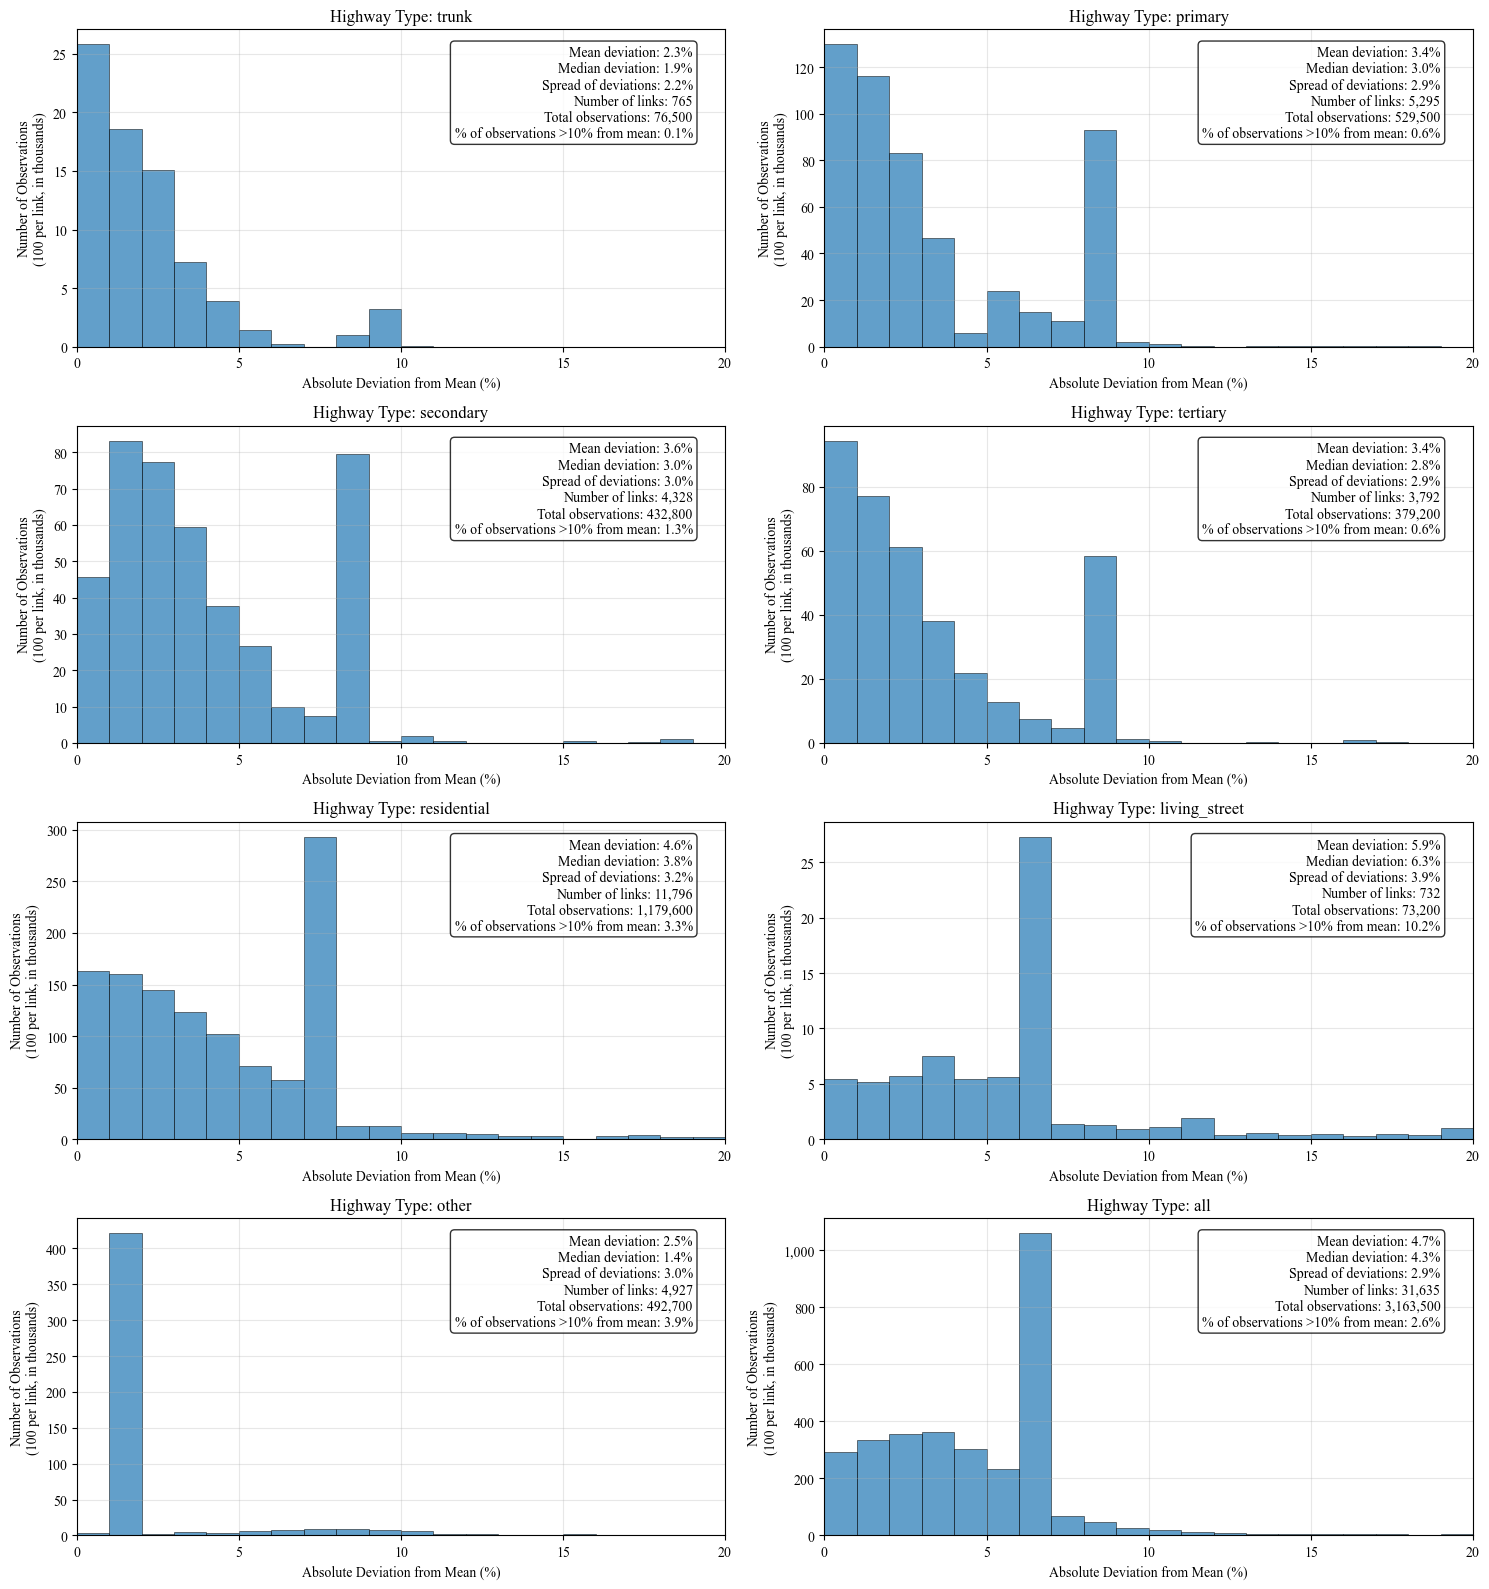


Detailed Summary Statistics by Highway Type (Grouped):

Highway type: trunk
Number of links: 765
Total observations: 76,500
Mean deviation from mean: 2.25%
Median deviation from mean: 1.86%
Spread of deviations: 2.18%
Minimum deviation: 0.19%
Maximum deviation: 10.02%
Percentage of observations >10% from mean: 0.13%
Original highway types in this group: trunk_link, trunk

Highway type: primary
Number of links: 5,295
Total observations: 529,500
Mean deviation from mean: 3.44%
Median deviation from mean: 2.98%
Spread of deviations: 2.91%
Minimum deviation: 0.08%
Maximum deviation: 20.33%
Percentage of observations >10% from mean: 0.64%
Original highway types in this group: primary, primary_link

Highway type: secondary
Number of links: 4,328
Total observations: 432,800
Mean deviation from mean: 3.61%
Median deviation from mean: 3.05%
Spread of deviations: 3.03%
Minimum deviation: 0.01%
Maximum deviation: 20.42%
Percentage of observations >10% from mean: 1.29%
Original highway types in t

In [32]:
# Create a function to group highway types
def group_highway_type(highway):
    if highway in ['primary', 'primary_link']:
        return 'primary'
    elif highway in ['secondary', 'secondary_link']:
        return 'secondary'
    elif highway in ['tertiary', 'tertiary_link']:
        return 'tertiary'
    elif highway in ['trunk', 'trunk_link']:
        return 'trunk'
    elif highway in ['residential', 'living_street']:
        return highway
    else:
        return 'other'

# Apply the grouping to the GeoDataFrame
gdf_basecase_mean['highway_group'] = gdf_basecase_mean['highway'].apply(group_highway_type)

# Set the font to Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'

# Define the desired order of highway groups
highway_order = ['trunk', 'primary', 'secondary', 'tertiary', 'residential', 'living_street', 'other']

# Get unique grouped highway types and sort them according to the desired order
highway_groups = sorted(gdf_basecase_mean['highway_group'].unique(), 
                       key=lambda x: highway_order.index(x) if x in highway_order else len(highway_order))

# Add 'all' to the highway groups
highway_groups = list(highway_groups) + ['all']

# Calculate number of rows and columns for subplots
n_groups = len(highway_groups)
n_cols = 2
n_rows = (n_groups + 1) // 2  # Ceiling division

# Create figure with subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()  # Flatten the axes array for easier indexing

# Create bins for the histogram (0 to 20 with 1% intervals)
bins = np.arange(0, 21, 1)  # Changed to 21 to include the 20 value

# Create a subplot for each highway group
for idx, highway in enumerate(highway_groups):
    # Filter data for this highway group
    if highway == 'all':
        highway_data = gdf_basecase_mean['outlier_percentage'].dropna()
    else:
        highway_data = gdf_basecase_mean[gdf_basecase_mean['highway_group'] == highway]['outlier_percentage'].dropna()
    
    # Calculate differences from mean for each link
    mean_diff = abs(highway_data - highway_data.mean())
    
    # Create histogram with fixed bins
    # We need to multiply each count by 100 since each link has 100 observations
    counts, bins, patches = axes[idx].hist(mean_diff, 
                                         bins=bins,
                                         alpha=0.7,
                                         edgecolor='black',
                                         linewidth=0.5,
                                         align='mid',
                                         weights=np.ones_like(mean_diff) * 100)  # Multiply each count by 100
    
    # Customize subplot
    axes[idx].set_title(f'Highway Type: {highway}', fontsize=12)
    axes[idx].set_xlabel('Absolute Deviation from Mean (%)', fontsize=10)
    axes[idx].set_ylabel('Number of Observations\n(100 per link, in thousands)', fontsize=10)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xlim(0, 20)  # Cut off x-axis at 20%
    
    # Set x-axis ticks to only show values at 0, 5, 10, 15, 20
    axes[idx].set_xticks([0, 5, 10, 15, 20])
    
    # Format y-axis ticks to show numbers in thousands with commas
    yticks = axes[idx].get_yticks()
    axes[idx].set_yticklabels([f'{int(x/1000):,}' for x in yticks])
    
    # Calculate percentage of observations deviating by more than 10% from their link's mean
    links_above_10 = (mean_diff > 10).sum()
    percentage_above_10 = (links_above_10 / len(highway_data)) * 100
    
    # Add statistics as text
    stats_text = f'Mean deviation: {mean_diff.mean():.1f}%\n'
    stats_text += f'Median deviation: {mean_diff.median():.1f}%\n'
    stats_text += f'Spread of deviations: {mean_diff.std():.1f}%\n'
    stats_text += f'Number of links: {len(highway_data):,}\n'
    stats_text += f'Total observations: {len(highway_data) * 100:,}\n'
    stats_text += f'% of observations >10% from mean: {percentage_above_10:.1f}%'
    axes[idx].text(0.95, 0.95, stats_text,
                  transform=axes[idx].transAxes,
                  verticalalignment='top',
                  horizontalalignment='right',
                  bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Remove any empty subplots
for idx in range(len(highway_groups), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()

# Save the plot with high resolution
plt.savefig('deviation_from_mean_by_highway_type.png', dpi=300, bbox_inches='tight')
plt.show()

# Print detailed summary statistics for each highway group in the specified order
print("\nDetailed Summary Statistics by Highway Type (Grouped):")
for highway in highway_groups:
    if highway == 'all':
        highway_data = gdf_basecase_mean['outlier_percentage'].dropna()
    else:
        highway_data = gdf_basecase_mean[gdf_basecase_mean['highway_group'] == highway]['outlier_percentage'].dropna()
    mean_diff = abs(highway_data - highway_data.mean())
    
    print(f"\nHighway type: {highway}")
    print(f"Number of links: {len(highway_data):,}")
    print(f"Total observations: {len(highway_data) * 100:,}")
    print(f"Mean deviation from mean: {mean_diff.mean():.2f}%")
    print(f"Median deviation from mean: {mean_diff.median():.2f}%")
    print(f"Spread of deviations: {mean_diff.std():.2f}%")
    print(f"Minimum deviation: {mean_diff.min():.2f}%")
    print(f"Maximum deviation: {mean_diff.max():.2f}%")
    
    # Calculate and print percentage of observations deviating by more than 10% from their link's mean
    links_above_10 = (mean_diff > 10).sum()
    percentage_above_10 = (links_above_10 / len(highway_data)) * 100
    print(f"Percentage of observations >10% from mean: {percentage_above_10:.2f}%")
    
    if highway != 'all':
        # Print original highway types in this group
        original_types = gdf_basecase_mean[gdf_basecase_mean['highway_group'] == highway]['highway'].unique()
        # Convert all types to strings and filter out any NaN values
        original_types = [str(t) for t in original_types if pd.notna(t)]
        print(f"Original highway types in this group: {', '.join(original_types)}")

/var/folders/m_/fjnjc1sn0ggc7z_2y7n27xfh0000gn/T/ipykernel_18832/2669113312.py:82: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[idx].set_yticklabels([f'{int(x/1000):,}' for x in yticks], fontsize=12)
/var/folders/m_/fjnjc1sn0ggc7z_2y7n27xfh0000gn/T/ipykernel_18832/2669113312.py:82: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[idx].set_yticklabels([f'{int(x/1000):,}' for x in yticks], fontsize=12)
/var/folders/m_/fjnjc1sn0ggc7z_2y7n27xfh0000gn/T/ipykernel_18832/2669113312.py:82: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[idx].set_yticklabels([f'{int(x/1000):,}' for x in yticks], fontsize=12)
/var/folders/m_/fjnjc1sn0ggc7z_2y7n27xfh0000gn/T/ipykernel_18832/2669113312.py:82: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[idx].set_yticklabels([f'{int(x/1000):,}' for x in yticks], fontsize=12)
/var/folders/m_/fjnjc1sn0ggc7z_2y7n27xfh0000gn/T/ipy

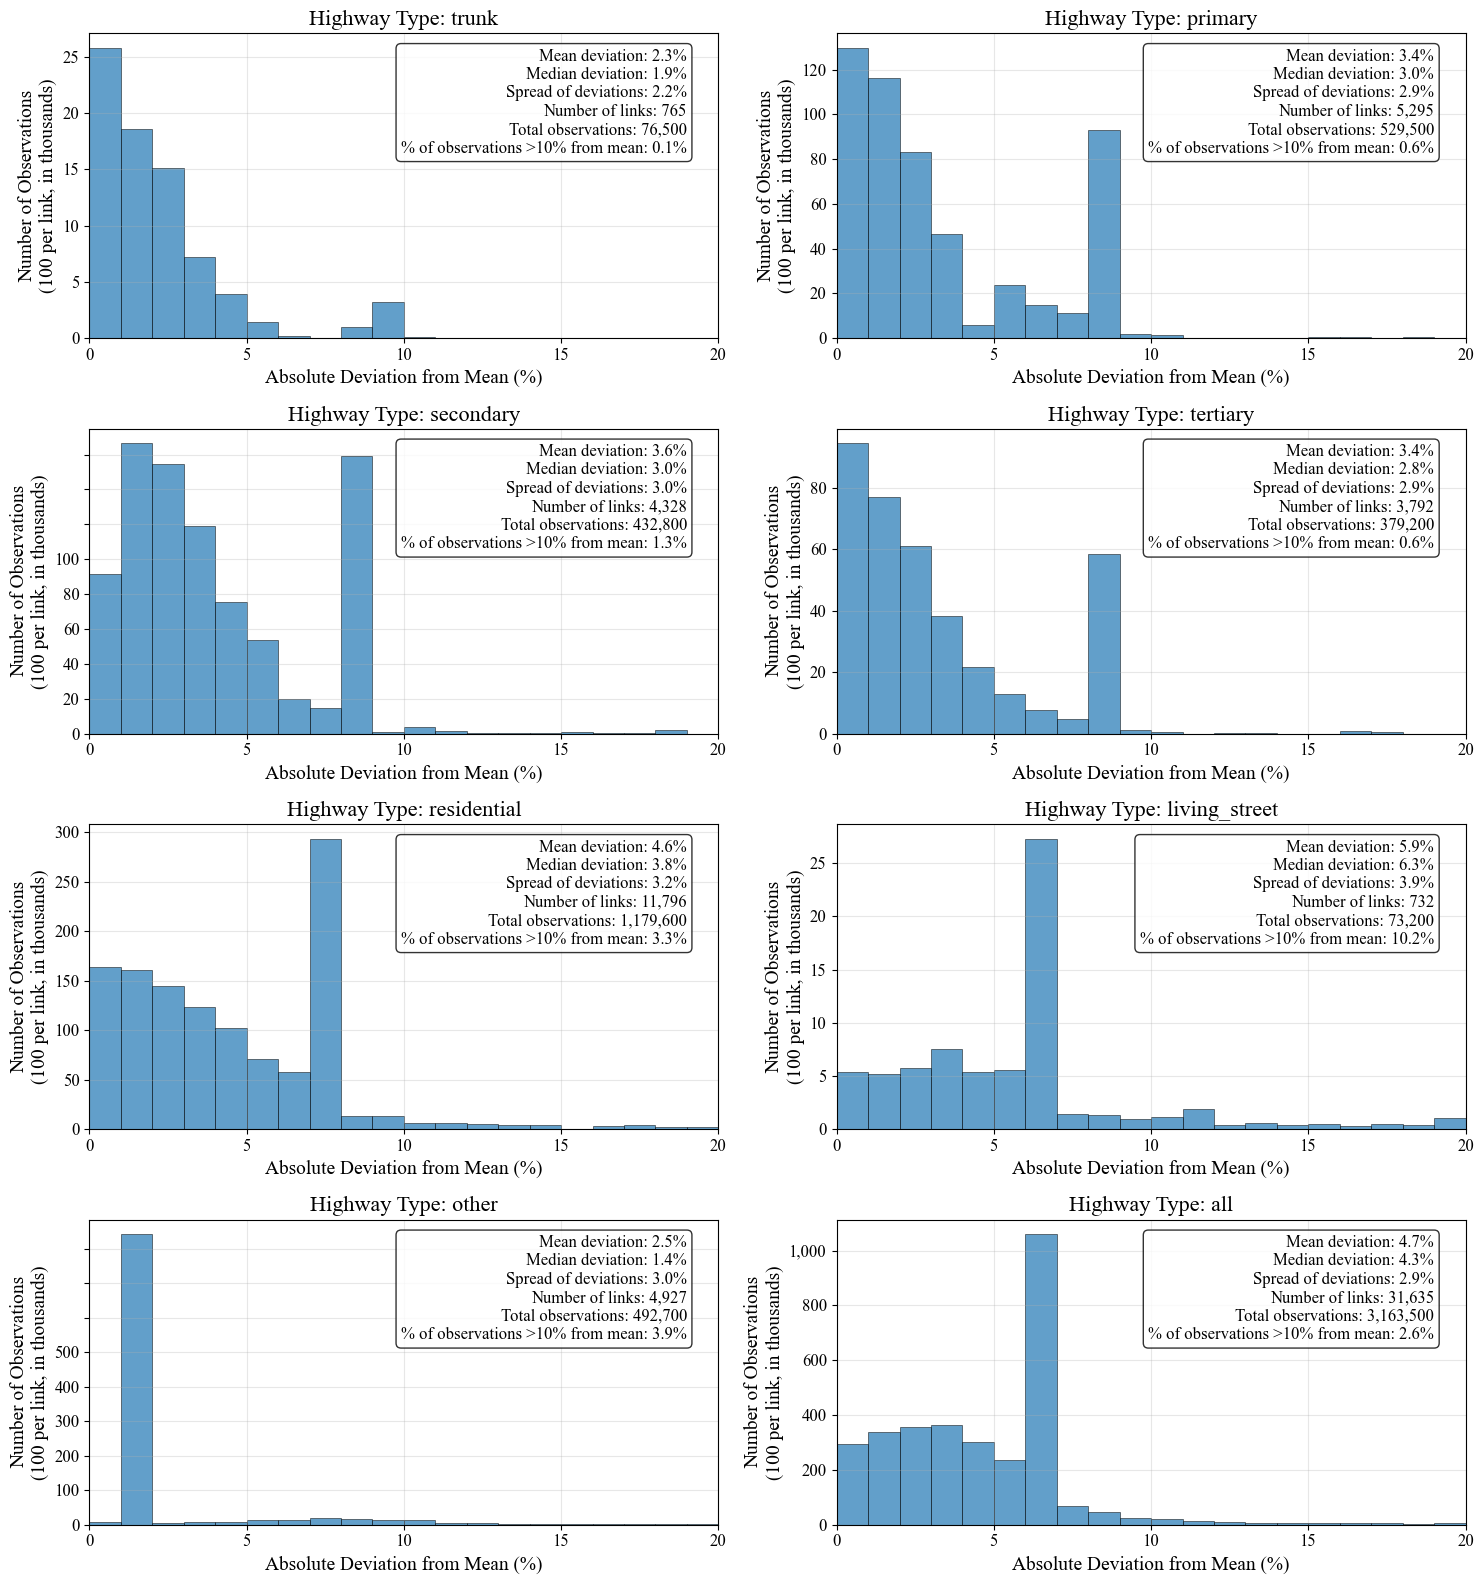


Detailed Summary Statistics by Highway Type (Grouped):

Highway type: trunk
Number of links: 765
Total observations: 76,500
Mean deviation from mean: 2.25%
Median deviation from mean: 1.86%
Spread of deviations: 2.18%
Minimum deviation: 0.19%
Maximum deviation: 10.02%
Percentage of observations >10% from mean: 0.13%
Original highway types in this group: trunk_link, trunk

Highway type: primary
Number of links: 5,295
Total observations: 529,500
Mean deviation from mean: 3.44%
Median deviation from mean: 2.98%
Spread of deviations: 2.91%
Minimum deviation: 0.08%
Maximum deviation: 20.33%
Percentage of observations >10% from mean: 0.64%
Original highway types in this group: primary, primary_link

Highway type: secondary
Number of links: 4,328
Total observations: 432,800
Mean deviation from mean: 3.61%
Median deviation from mean: 3.05%
Spread of deviations: 3.03%
Minimum deviation: 0.01%
Maximum deviation: 20.42%
Percentage of observations >10% from mean: 1.29%
Original highway types in t

In [33]:
# Create a function to group highway types
def group_highway_type(highway):
    if highway in ['primary', 'primary_link']:
        return 'primary'
    elif highway in ['secondary', 'secondary_link']:
        return 'secondary'
    elif highway in ['tertiary', 'tertiary_link']:
        return 'tertiary'
    elif highway in ['trunk', 'trunk_link']:
        return 'trunk'
    elif highway in ['residential', 'living_street']:
        return highway
    else:
        return 'other'

# Apply the grouping to the GeoDataFrame
gdf_basecase_mean['highway_group'] = gdf_basecase_mean['highway'].apply(group_highway_type)

# Set the font to Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12  # Increase base font size
plt.rcParams['axes.labelsize'] = 14  # Increase axis label size
plt.rcParams['axes.titlesize'] = 16  # Increase title size
plt.rcParams['xtick.labelsize'] = 12  # Increase tick label size
plt.rcParams['ytick.labelsize'] = 12  # Increase tick label size

# Define the desired order of highway groups
highway_order = ['trunk', 'primary', 'secondary', 'tertiary', 'residential', 'living_street', 'other']

# Get unique grouped highway types and sort them according to the desired order
highway_groups = sorted(gdf_basecase_mean['highway_group'].unique(), 
                       key=lambda x: highway_order.index(x) if x in highway_order else len(highway_order))

# Add 'all' to the highway groups
highway_groups = list(highway_groups) + ['all']

# Calculate number of rows and columns for subplots
n_groups = len(highway_groups)
n_cols = 2
n_rows = (n_groups + 1) // 2  # Ceiling division

# Create figure with subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()  # Flatten the axes array for easier indexing

# Create bins for the histogram (0 to 20 with 1% intervals)
bins = np.arange(0, 21, 1)  # Changed to 21 to include the 20 value

# Create a subplot for each highway group
for idx, highway in enumerate(highway_groups):
    # Filter data for this highway group
    if highway == 'all':
        highway_data = gdf_basecase_mean['outlier_percentage'].dropna()
    else:
        highway_data = gdf_basecase_mean[gdf_basecase_mean['highway_group'] == highway]['outlier_percentage'].dropna()
    
    # Calculate differences from mean for each link
    mean_diff = abs(highway_data - highway_data.mean())
    
    # Create histogram with fixed bins
    # We need to multiply each count by 100 since each link has 100 observations
    counts, bins, patches = axes[idx].hist(mean_diff, 
                                         bins=bins,
                                         alpha=0.7,
                                         edgecolor='black',
                                         linewidth=0.5,
                                         align='mid',
                                         weights=np.ones_like(mean_diff) * 100)  # Multiply each count by 100
    
    # Customize subplot
    axes[idx].set_title(f'Highway Type: {highway}', fontsize=16)
    axes[idx].set_xlabel('Absolute Deviation from Mean (%)', fontsize=14)
    axes[idx].set_ylabel('Number of Observations\n(100 per link, in thousands)', fontsize=14)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xlim(0, 20)  # Cut off x-axis at 20%
    
    # Set x-axis ticks to only show values at 0, 5, 10, 15, 20
    axes[idx].set_xticks([0, 5, 10, 15, 20])
    
    # Format y-axis ticks to show numbers in thousands with commas
    yticks = axes[idx].get_yticks()
    axes[idx].set_yticklabels([f'{int(x/1000):,}' for x in yticks], fontsize=12)
    
    # Calculate percentage of observations deviating by more than 10% from their link's mean
    links_above_10 = (mean_diff > 10).sum()
    percentage_above_10 = (links_above_10 / len(highway_data)) * 100
    
    # Add statistics as text
    stats_text = f'Mean deviation: {mean_diff.mean():.1f}%\n'
    stats_text += f'Median deviation: {mean_diff.median():.1f}%\n'
    stats_text += f'Spread of deviations: {mean_diff.std():.1f}%\n'
    stats_text += f'Number of links: {len(highway_data):,}\n'
    stats_text += f'Total observations: {len(highway_data) * 100:,}\n'
    stats_text += f'% of observations >10% from mean: {percentage_above_10:.1f}%'
    axes[idx].text(0.95, 0.95, stats_text,
                  transform=axes[idx].transAxes,
                  verticalalignment='top',
                  horizontalalignment='right',
                  bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                  fontsize=12)  # Increase statistics text size

# Remove any empty subplots
for idx in range(len(highway_groups), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()

# Save the plot with high resolution
plt.savefig('deviation_from_mean_by_highway_type.png', dpi=300, bbox_inches='tight')
plt.show()

# Print detailed summary statistics for each highway group in the specified order
print("\nDetailed Summary Statistics by Highway Type (Grouped):")
for highway in highway_groups:
    if highway == 'all':
        highway_data = gdf_basecase_mean['outlier_percentage'].dropna()
    else:
        highway_data = gdf_basecase_mean[gdf_basecase_mean['highway_group'] == highway]['outlier_percentage'].dropna()
    mean_diff = abs(highway_data - highway_data.mean())
    
    print(f"\nHighway type: {highway}")
    print(f"Number of links: {len(highway_data):,}")
    print(f"Total observations: {len(highway_data) * 100:,}")
    print(f"Mean deviation from mean: {mean_diff.mean():.2f}%")
    print(f"Median deviation from mean: {mean_diff.median():.2f}%")
    print(f"Spread of deviations: {mean_diff.std():.2f}%")
    print(f"Minimum deviation: {mean_diff.min():.2f}%")
    print(f"Maximum deviation: {mean_diff.max():.2f}%")
    
    # Calculate and print percentage of observations deviating by more than 10% from their link's mean
    links_above_10 = (mean_diff > 10).sum()
    percentage_above_10 = (links_above_10 / len(highway_data)) * 100
    print(f"Percentage of observations >10% from mean: {percentage_above_10:.2f}%")
    
    if highway != 'all':
        # Print original highway types in this group
        original_types = gdf_basecase_mean[gdf_basecase_mean['highway_group'] == highway]['highway'].unique()
        # Convert all types to strings and filter out any NaN values
        original_types = [str(t) for t in original_types if pd.notna(t)]
        print(f"Original highway types in this group: {', '.join(original_types)}")